In [1]:
# 导入数据分析库和科学计算库
import pandas as pd
import numpy as np
# 导入绘图库
from matplotlib import pyplot as plt
import seaborn as sns
# 导入决策树模块
from sklearn.tree import DecisionTreeRegressor
# 导入数据划分模块
from sklearn.model_selection import train_test_split
# 导入数据标准化模块
from sklearn.preprocessing import StandardScaler
# 导入 R2 分数模块
from sklearn.metrics import r2_score

In [2]:
# 加载数据
data = pd.read_csv('Salary_Data.csv')

# 数据编码
EC = {
    'Gender': {
        'Male': 1,
        'Female': 0
    },
    'Education Level': {
        'Bachelor': 0,
        'Master': 1,
        'PhD': 2
    },
}

for column in data:
    if column in EC.keys():
        try:
            data[column] = data[column].apply(lambda x: EC[column][x])
        except:
            print(f"Skipped {column}")

print('数据基本信息:', data.shape)  # 显示数据基本信息（样本数与特征数）

数据基本信息: (40, 5)


In [3]:
# 拆出用于预测的数据和最终预测的结果
x = data.drop('Salary', axis=1)
y = data['Salary']

In [4]:
x

,Age,Gender,Education Level,Years of Experience
0,32,1,0,5
1,28,0,1,3
2,45,1,2,15
3,36,0,0,7
4,52,1,1,20
5,29,1,0,2
6,42,0,1,12
7,31,1,0,4
8,26,0,0,1
9,38,1,2,10


In [5]:
y

0      90000
1      65000
2     150000
3      60000
4     200000
5      55000
6     120000
7      80000
8      45000
9     110000
10     75000
11    140000
12     65000
13    130000
14     40000
15    125000
16     90000
17    115000
18     35000
19    180000
20     80000
21    190000
22     50000
23     60000
24    140000
25     45000
26    110000
27     40000
28    140000
29     90000
30    250000
31     55000
32     75000
33     65000
34    170000
35     45000
36     60000
37    115000
38     40000
39    160000
Name: Salary, dtype: int64

1.  期望的线性性质：
    $$E(X+Y) = E(X) + E(Y)$$

2.  方差的性质（和差公式）：
    $$D(X \pm Y) = D(X) + D(Y) \pm 2\text{Cov}(X, Y)$$

3.  协方差的计算公式：
    $$\text{Cov}(X, Y) = E(XY) - E(X)E(Y)$$

4.  相关系数公式：
    $$\rho_{XY} = \frac{\text{cov}(X, Y)}{\sqrt{D(X)} \cdot \sqrt{D(Y)}}$$

下面的 `corr` 方法用于计算相关系数矩阵，上学的概率统计中我们知道，系数矩阵用于描述数据的相关性，值大于 1 代表正相关，小于 1 代表负相关，0 即为不相关。


In [6]:
# 特征相关性分析
corr = x[x.columns[0:]].corr()
corr

,Age,Gender,Education Level,Years of Experience
Age,1.000000,0.203640,0.316449,0.980091
Gender,0.203640,1.000000,0.127668,0.220493
Education Level,0.316449,0.127668,1.000000,0.313889
Years of Experience,0.980091,0.220493,0.313889,1.000000


从上述的输出中我们不难发现，Age 与 Year of Experience 成显著正相关，这样符合直觉——年龄越大、经验越多

此外，我们还发现一个特性 **相关系数矩阵是一个对称矩阵** 。

[Text(0.5, 0, 'Age'),
 Text(1.5, 0, 'Gender'),
 Text(2.5, 0, 'Education Level'),
 Text(3.5, 0, 'Years of Experience')]

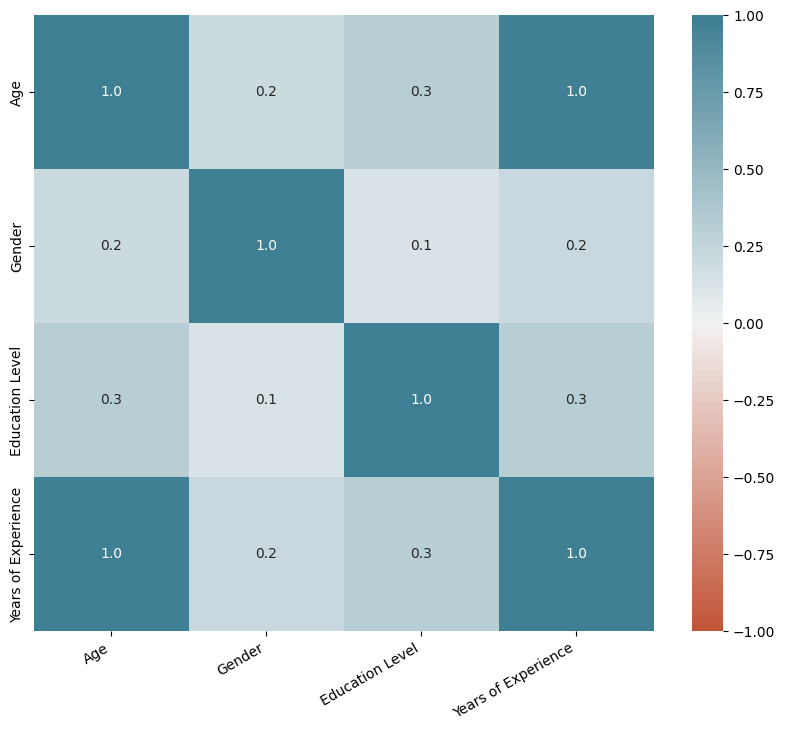

In [7]:
# 这里就是把这个系数矩阵绘制成一个 相关系数热力图 ，颜色的深浅意味着两个属性之间的相关性不一样
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=False, annot=True, fmt='.1f')
ax.set_xticklabels(
    ax.get_xticklabels(),  # 获取 x 轴刻度标签文本
    rotation=30,
    horizontalalignment='right'
)

In [8]:
# 这里在做数据的归一化，将大范围的数据映射到一个小范围，使数据易于拟合
scaler = StandardScaler()
x_ = scaler.fit_transform(x)

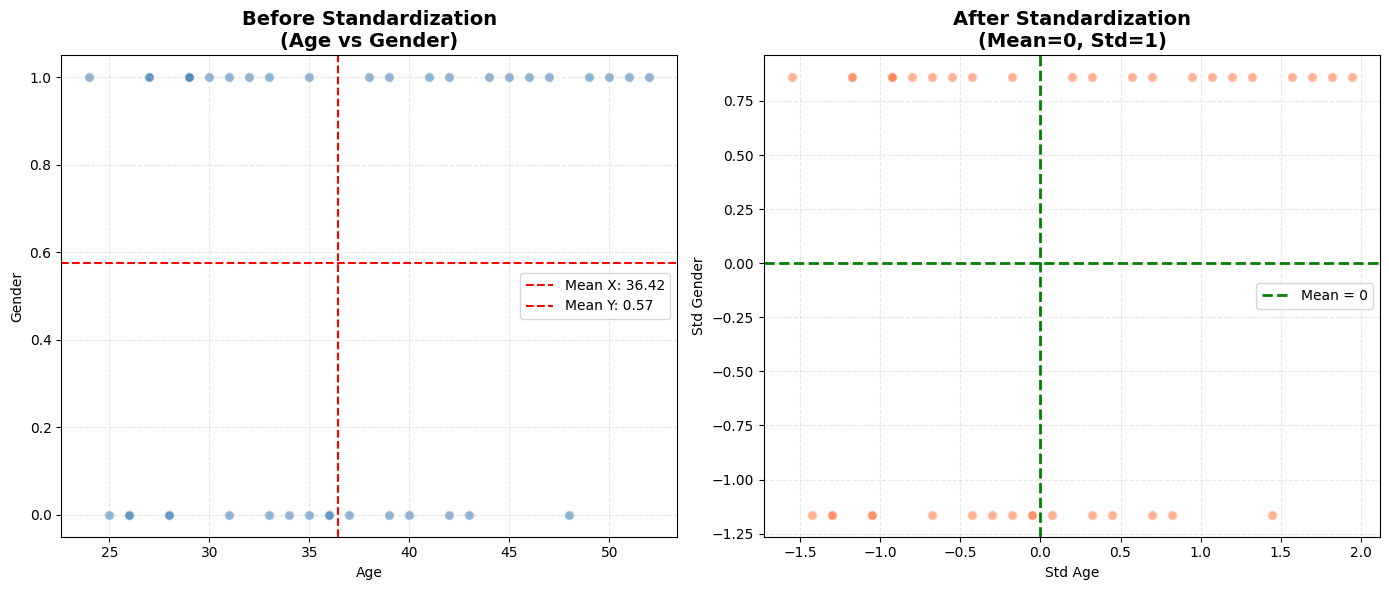

In [9]:
feature_names = x.columns[:2]
x_raw_plot = x[feature_names]       # 原始数据
x_std_plot = x_[:, :2]              # 标准化后的数据 (取前两列)

# 2. 创建画布：1行2列，大小为 (14, 6)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 左图：标准化前 ---
axes[0].scatter(x_raw_plot.iloc[:, 0], x_raw_plot.iloc[:, 1],
                c='steelblue', alpha=0.6, edgecolors='w', s=50)
axes[0].set_title(f'Before Standardization\n({feature_names[0]} vs {feature_names[1]})', fontsize=14, fontweight='bold')
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].grid(True, linestyle='--', alpha=0.3)
# 标注原始数据的均值
mean_raw_0 = x_raw_plot.iloc[:, 0].mean()
mean_raw_1 = x_raw_plot.iloc[:, 1].mean()
axes[0].axvline(mean_raw_0, color='red', linestyle='--', label=f'Mean X: {mean_raw_0:.2f}')
axes[0].axhline(mean_raw_1, color='red', linestyle='--', label=f'Mean Y: {mean_raw_1:.2f}')
axes[0].legend()

# --- 右图：标准化后 ---
axes[1].scatter(x_std_plot[:, 0], x_std_plot[:, 1],
                c='coral', alpha=0.6, edgecolors='w', s=50)
axes[1].set_title('After Standardization\n(Mean=0, Std=1)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'Std {feature_names[0]}')
axes[1].set_ylabel(f'Std {feature_names[1]}')
axes[1].grid(True, linestyle='--', alpha=0.3)
# 标注标准化后的均值 (理论上应该是 0)
axes[1].axvline(0, color='green', linestyle='--', linewidth=2, label='Mean = 0')
axes[1].axhline(0, color='green', linestyle='--', linewidth=2)
axes[1].legend()

plt.tight_layout()
plt.show()

上述的两幅图，是我让 AI 绘制的归于化前和归一化之后的对比，两幅图的数据分布情况是一致的，但是在归一化之后，坐标轴的刻度被重新划分在了原点附近。

In [10]:
# 将数据划分为训练数据与测试数据
x_train, x_test, y_train, y_test = train_test_split(x_, y, test_size=0.3)

In [11]:
# 构建决策树模型（不同深度）
depth_list = np.arange(2, 10, 1)
R2_Train = []  # 保存训练样本拟合优度
R2_Test = []  # 保存测试样本拟合优度
for i in depth_list:
    DT = DecisionTreeRegressor(max_depth=i)
    DT.fit(x_train, y_train)  # 训练决策树
    R2_Train.append(r2_score(y_train, DT.predict(x_train)))
    R2_Test.append(r2_score(y_test, DT.predict(x_test)))

In [12]:
# 查看结果功能会落到的最终的值
y.drop_duplicates().sort_values()

18     35000
14     40000
8      45000
22     50000
5      55000
3      60000
1      65000
10     75000
7      80000
0      90000
9     110000
17    115000
6     120000
15    125000
13    130000
11    140000
2     150000
39    160000
34    170000
19    180000
21    190000
4     200000
30    250000
Name: Salary, dtype: int64

上述的决策树训练和误差估计我做如下解释：

1. 预测的结果是这个人的薪水(Salary)，而 Salary 的取值只有 35000、40000、45000 等，在我们的训练数据中是离散的，不是连续的。
2. 因为最后的预测结果是一个数，所以可以使用 $R^2$ 分数来计算决定系数（这个模型到底好不好）

$R^2$ 的计算公式如下：

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

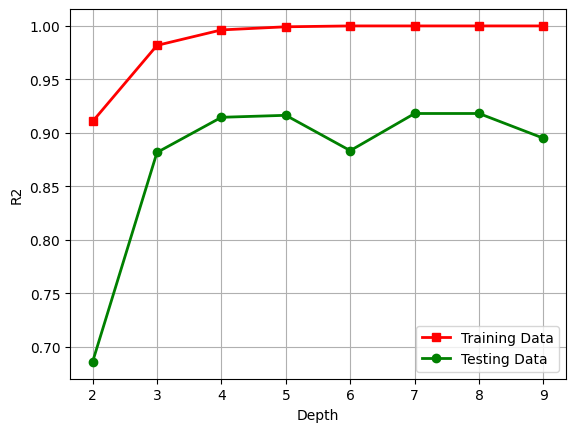

In [13]:
# 展示不同深度的决策树在测试集上的表现
plt.figure(2)
plt.plot(depth_list, R2_Train, color='r', marker='s', label='Training Data', linewidth=2)
plt.plot(depth_list, R2_Test, color='g', marker='o', label='Testing Data', linewidth=2)
plt.xlabel('Depth')
plt.ylabel('R2')
plt.legend(loc='best')
plt.grid(True)
plt.show()

上图可以观察出，当决策树深度为 9 的时候，在测试集上的表现最好（$R^2$ 越高越好）

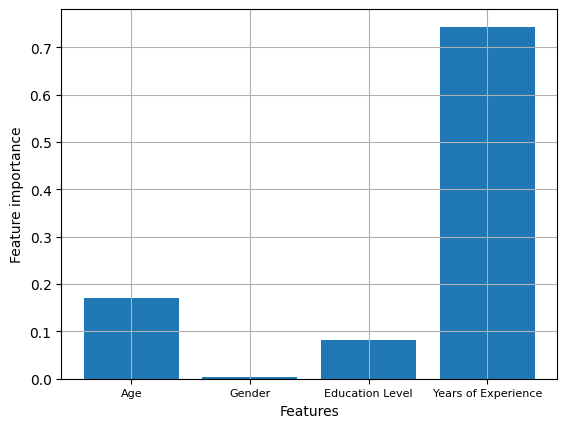

[0.1704088  0.00406332 0.08172671 0.74380117]


In [15]:
# 特征重要性
DT = DecisionTreeRegressor(max_depth=5)  # 我们选择最好的
DT.fit(x_train, y_train)

# 特征数
n_features = data.shape[1]
plt.figure(3)
plt.bar(np.arange(1, n_features, 1), np.array(DT.feature_importances_), align='center')
plt.xticks(np.arange(1, n_features, 1), data.columns[:-1], fontsize=8)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.grid(True)
plt.show()

print(DT.feature_importances_)

上述的图中我们可以看出，薪水水平和人的年龄、教育水平、经验比较相关，而与性别相关性较差。

但是由于数据量不足，每次训练集分划分结果都不一样。